<a href="https://colab.research.google.com/github/CassioLima09/NLP_with_Transformers/blob/main/07_question_answering_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run this cell if you're on Colab or Kaggle
!git clone https://github.com/nlp-with-transformers/notebooks.git
%cd notebooks
from install import *
install_requirements(is_chapter7_v2=True)

In [ ]:
!pip install transformers datasets accelerate evaluate matplotlib pandas

In [ ]:
from utils import *
setup_chapter()

In [ ]:
%env TOKENIZERS_PARALLELISM=false
# define uma variavel de ambiente
# os tokenizadores serao processados de forma nao paralela e isso evita conflitos


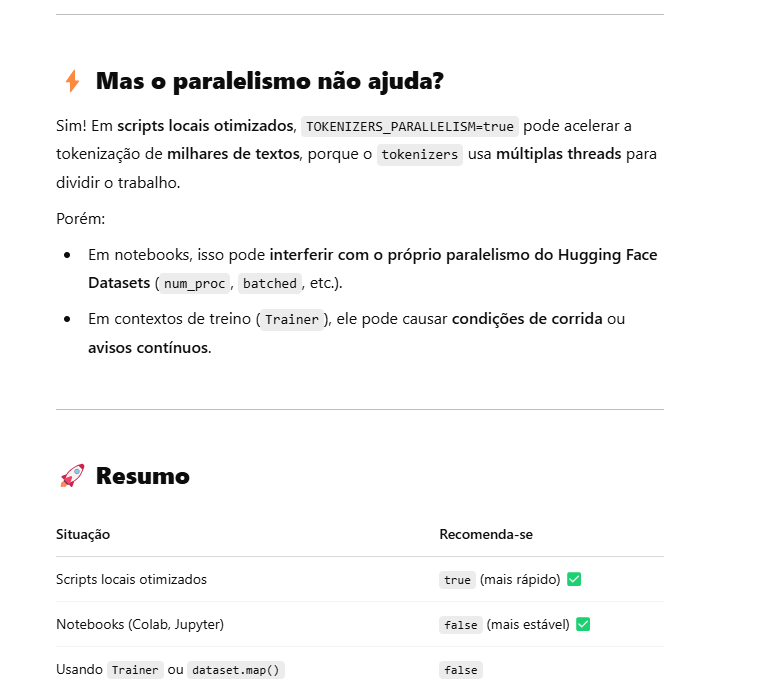

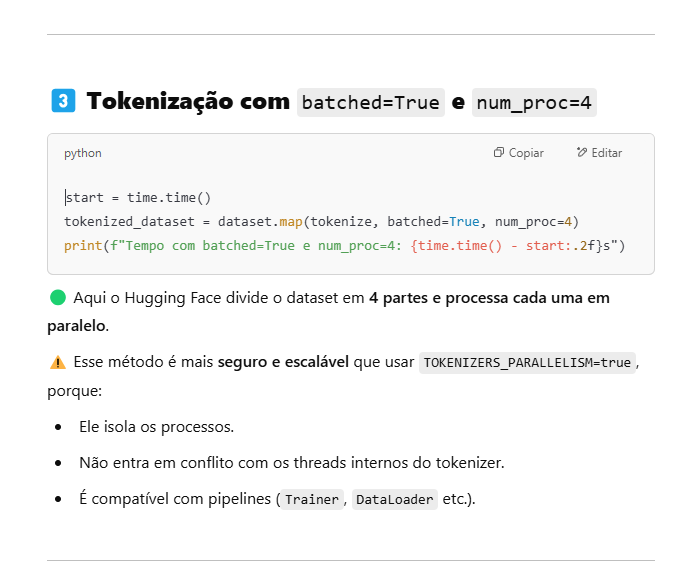

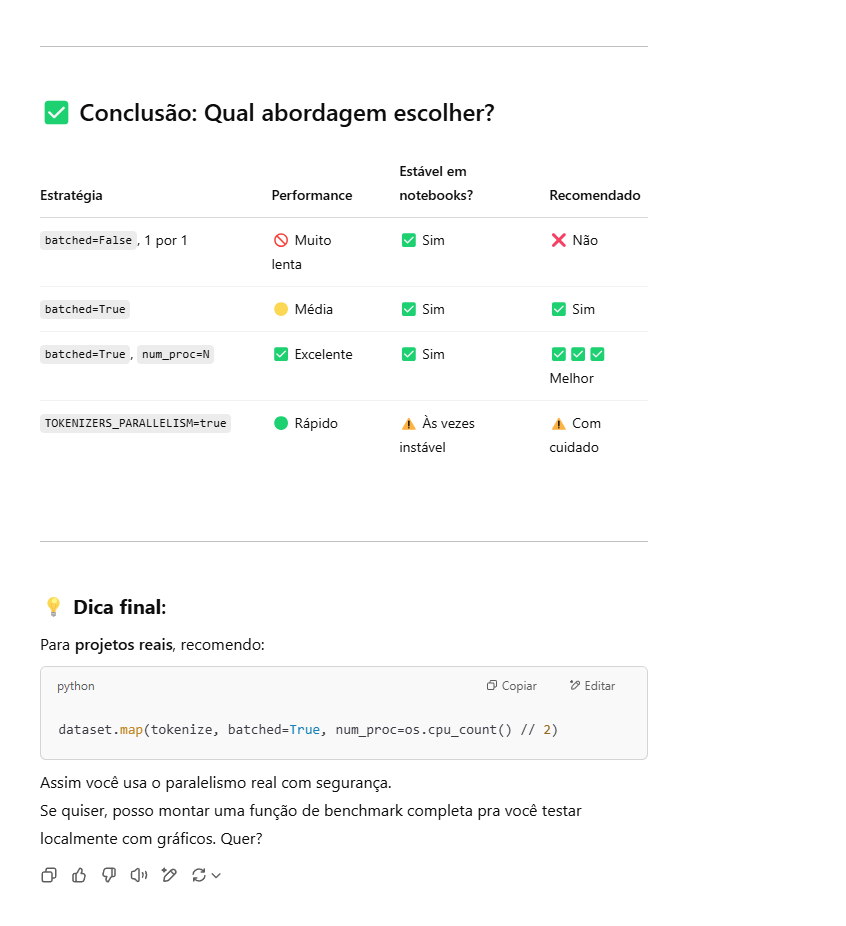

In [ ]:
# Suppress Haystack logging
import logging
for module in ["farm.utils", "farm.infer", "haystack.reader.farm.FARMReader",
              "farm.modeling.prediction_head", "elasticsearch", "haystack.eval",
               "haystack.document_store.base", "haystack.retriever.base",
              "farm.data_handler.dataset"]:
    module_logger = logging.getLogger(module)
    module_logger.setLevel(logging.ERROR)

    #O módulo logging do Python é usado para exibir mensagens de depuração, erros,
   #  avisos e outros tipos de eventos durante a execução do código.
   # .setLevel(logging.ERROR) Isso faz com que somente mensagens de nível ERROR ou superior (como CRITICAL) sejam mostradas.
# Mensagens do tipo INFO, DEBUG e WARNING são escondidas.

# Question Answering

<img alt="Marie Curie" width="500" caption="A Google search query and corresponding answer snippet" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_marie-curie.png?raw=1" id="marie-curie"/>

## Building a Review-Based QA System

### The Dataset

<img alt="Phone with Query" width="400" caption="A question about a product and the corresponding review (the answer span is underlined)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_phone.png?raw=1" id="phone"/>

In [ ]:
from datasets import get_dataset_config_names

domains = get_dataset_config_names("subjqa") #Retorna as configurações disponíveis para esse dataset
domains
# cada um dos dominios apresenta um dataset com QA sobre aquele ramo especifico

In [ ]:
from datasets import load_dataset
# agora que pegamos os nomes acima, podemos selecionar o que queremos do dataser

subjqa = load_dataset("subjqa", name="electronics")

In [ ]:
print(subjqa["train"]["answers"][1])

In [ ]:
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}
#subjqa.flatten() → transforma os splits (train, test) em um formato plano para iteração.

for split, df in dfs.items():
    print(f"Number of questions in {split}: {df['id'].nunique()}")

In [ ]:
qa_cols = ["title", "question", "answers.text",
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

In [ ]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

In [ ]:
# vamos ver quantas perguntas iniciam com palavras que sao comuns
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

In [ ]:
# vamos ver um exemplo das mais comuns que apareceram
for question_type in ["How", "What", "Is"]:
    for question in (
        dfs["train"][dfs["train"].question.str.startswith(question_type)]
        .sample(n=3, random_state=42)['question']):
        print(question)

### Sidebar: The Stanford Question Answering Dataset

<img alt="SQuAD SotA" width="600" caption="Progress on the SQuAD 2.0 benchmark (image from Papers with Code)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-sota.png?raw=1" id="squad-sota"/>

### End sidebar

### Extracting Answers from Text

#### Span classification

<img alt="QA Head" caption="The span classification head for QA tasks" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_qa-head.png?raw=1" id="qa-head"/>

Claro! Vamos entender **em detalhes** o que significa essa afirmação sobre **span classification**.

---

### 📌 Texto da imagem:

> The most common way to extract answers from text is by framing the problem as a **span classification** task, where the start and end tokens of an answer span act as the labels that a model needs to predict.

---

## ✅ O que é "span classification"?

É uma **técnica usada em tarefas de Pergunta e Resposta (Question Answering)** em que o modelo **não gera uma resposta nova**, mas **seleciona um trecho (span)** do texto original como resposta.

### 📘 Exemplo prático:

Suponha a seguinte pergunta e contexto:

**Pergunta:**  
> Qual é a cor do céu?

**Contexto:**  
> O céu é geralmente azul durante o dia, mas pode ficar laranja ao entardecer.

**Resposta esperada:**  
> azul

---

## 🧠 Como o modelo responde?

O modelo **não precisa gerar a palavra "azul" do zero**. Em vez disso, ele **classifica qual é o intervalo de tokens (span)** dentro do texto que contém a resposta.

🔸 Ele prevê dois índices:
- Um para o **início da resposta** no texto (`start_token`)
- Um para o **fim da resposta** no texto (`end_token`)

Esses dois índices definem o trecho da resposta.

---

## 🔍 Por que isso é útil?

- É **mais eficiente** do que gerar tokens como na geração de texto.
- Evita erros de fluência — a resposta já está no contexto.
- Muito usado em modelos como BERT e seus derivados para tarefas de QA (ex: SQuAD, SubjQA).

---

## 🏷️ “Act as labels” significa o quê?

No treinamento:
- O modelo recebe a pergunta e o texto.
- Os **índices reais** do início e fim da resposta são os **rótulos (labels)**.
- O modelo aprende a prever esses dois pontos corretamente.

---

## 🔁 Em resumo:

| Termo | Significado |
|-------|-------------|
| **Span** | Um trecho (subsequência de tokens) no texto. |
| **Span classification** | Modelo aprende a prever **onde** a resposta começa e termina no contexto. |
| **Labels** | Os índices de início e fim da resposta — o que o modelo precisa aprender a prever. |



<img alt="SQuAD models" width="600" caption="A selection of extractive QA models on the Hugging Face Hub" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-models.png?raw=1" id="squad-models"/>

#### Tokenizing text for QA

In [ ]:
from transformers import AutoTokenizer
# esse modelo já foi pré-treinado para QA
model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""
# vamos ver o modelo em ação sem qlquer ajuste
inputs = tokenizer(question, context, return_tensors="pt")

In [ ]:
#hide_input
input_df = pd.DataFrame.from_dict(tokenizer(question, context), orient="index")
input_df

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))
# vamos ver como o tokenizador funciona trazendo de volta para texto

In [ ]:
import torch
from transformers import AutoModelForQuestionAnswering
# ao fazer esse import o transformers coloca uma cabeça no seu modelo adequada para a tarefa que voce quer entregar
# AutoModelForQuestionAnswering faz um previsao queRetorna o início e fim da resposta no texto

model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)
# vamos gerar uma saida com o modelo
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)
# veja que tem uma série de logits com a pontuaçao de cada palavra para iniciar e terminar a sentença
# PARA CADA PALAVRA DO MEU INPUT (A PERGUNTA E A RESPOSTA) EU TENHO UM LOGIT ASSOCIADO A ESSA PALAVRA INDICANDO
# SUA PONTUAÇAO PARA INICIAR E PARA TERMINAR A RESPOSTA

In [ ]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [ ]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")
#VEJA QUE CADA PALAVRA DO INPUT TEM UM LOGIT ASSOCIADO QUE INDICA SUA CHANCE DE INICIAR E DE TERMINAR A RESPOTA

In [ ]:
#hide_input
#id qa-scores
#caption Predicted logits for the start and end tokens—the token with the highest score is colored in orange

# The idea for this visualisation comes from https://mccormickml.com/2020/03/10/question-answering-with-a-fine-tuned-BERT
import numpy as np
import matplotlib.pyplot as plt

s_scores = start_logits.detach().numpy().flatten()
e_scores = end_logits.detach().numpy().flatten()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
token_ids = range(len(tokens))

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
colors = ["C0" if s != np.max(s_scores) else "C1" for s in s_scores]
ax1.bar(x=token_ids, height=s_scores, color=colors)
ax1.set_ylabel("Start Scores")
colors = ["C0" if s != np.max(e_scores) else "C1" for s in e_scores]
ax2.bar(x=token_ids, height=e_scores, color=colors)
ax2.set_ylabel("End Scores")
plt.xticks(token_ids, tokens, rotation="vertical")
plt.show()

In [ ]:
import torch
# AGORA VAMOS EXTRAIR A PALAVRA COM MAIOR LOGIT PARA INICIAR A RESPOTA
# E A PALAVRA COM MAIOR LOGIT PARA TERMINAR A RESPOSTA
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question: {question}")
print(f"Answer: {answer}")

**In our simple example, we obtained the start and end indices by taking the argmax of the corresponding logits. However, this heuristic can produce out-of-scope answers by selecting tokens that belong to the question instead of the context. In practice, the pipeline computes the best combination of start and end indices subject to various constraints such as being in-scope, requiring the start indices to precede the end indices, and so on.**

In [ ]:
from transformers import pipeline
# vejamos agora um pipeline que já faz exatamente isso para nós

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
#pipe(question=question, context=context, topk=3)

In [ ]:
#IMPORTANTE: QUANDO NOSSO MODELO NAO CONSEGUIR ACHAR PALAVRAS COM BOAS PROBABILIDADES DE SEREM A RESPOSTA
# DENTRO DO NOSO CONTEXTO, A SAÍDA DO MODELO SERÁ QUE O CLS SERÁ O INICIO E FIM D ARESPOSTA
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""

pipe(question="Why is there no data?", context=context,
     handle_impossible_answer=True)
# VEJA QUE A PERGUNTA NAO TEM RELAÇÃO COM O CONTEXTO

#### Dealing with long passages

In [ ]:
#hide_input
#id subjqa-dist
#caption Distribution of tokens for each question-context pair in the SubjQA training set
def compute_input_length(row):
    inputs = tokenizer(row["question"], row["context"])
    return len(inputs["input_ids"])

dfs["train"]["n_tokens"] = dfs["train"].apply(compute_input_length, axis=1)

fig, ax = plt.subplots()
dfs["train"]["n_tokens"].hist(bins=100, grid=False, ec="C0", ax=ax)
plt.xlabel("Number of tokens in question-context pair")
ax.axvline(x=512, ymin=0, ymax=1, linestyle="--", color="C1",
           label="Maximum sequence length")
plt.legend()
plt.ylabel("Count")
plt.show()

One subtlety faced by reading comprehension models is that the context often contains more tokens than the maximum sequence length of the model (which is usually a few hundred tokens at most). As illustrated in Figure 7-7, a decent portion of the SubjQA training set contains question-context pairs that won’t fit within MiniLM’s context size of 512 tokens.

For other tasks, like text classification, we simply truncated long texts under the assumption that enough information was contained in the embedding of the [CLS] token to generate accurate predictions. For QA, however, this strategy is problematic because the answer to a question could lie near the end of the context and thus would be removed by truncation. As illustrated in Figure 7-8, the standard way to deal with this is to apply a sliding window across the inputs, where each window contains a passage of tokens that fit in the model’s context.

<img alt="Sliding window" caption="How the sliding window creates multiple question-context pairs for long documents—the first bar corresponds to the question, while the second bar is the context captured in each window" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_sliding-window.png?raw=1" id="sliding-window"/>

In [ ]:
# VEJA que criamos slide windows para que o nosso contexto nao ultrapasse o a janela de contexto do modelo
# Ou seja, o modelo nao consegue processar todos os tokens que inserimos no contexto por uma limitação do proprio modelo
# para adequar isso precisamos criar varias janelas para a pergunta e assim identificamos o inicio e fim da resposta corretamente
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],
                              return_overflowing_tokens=True, max_length=100,
                              stride=25)

# return_overflowing_tokens=True habilitamos a slide window
# max_length=100 controla o tamanho da slide window
# o stride é o passo, que fica evidente na imagem acima

In [ ]:
# pegamos uma lista de inputs_ids, uma para cada janela
# vamos verificar quantos tokens temos em cada uma das janelas
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"Window #{idx} has {len(window)} tokens")

In [ ]:
# vejamso como essas janelas sao desenhadas ( a question permanece intacta)
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

### Using Haystack to Build a QA Pipeline

<img alt="QA Architecture" caption="The retriever-reader architecture for modern QA systems" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_retriever-reader.png?raw=1" id="retriever-reader"/>

#### Initializing a document store

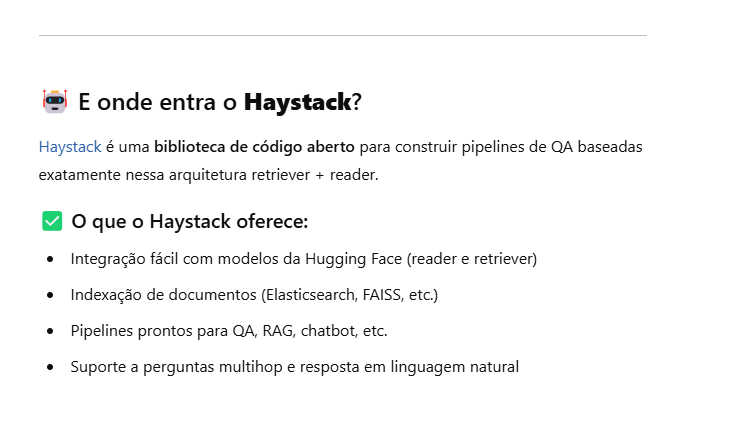

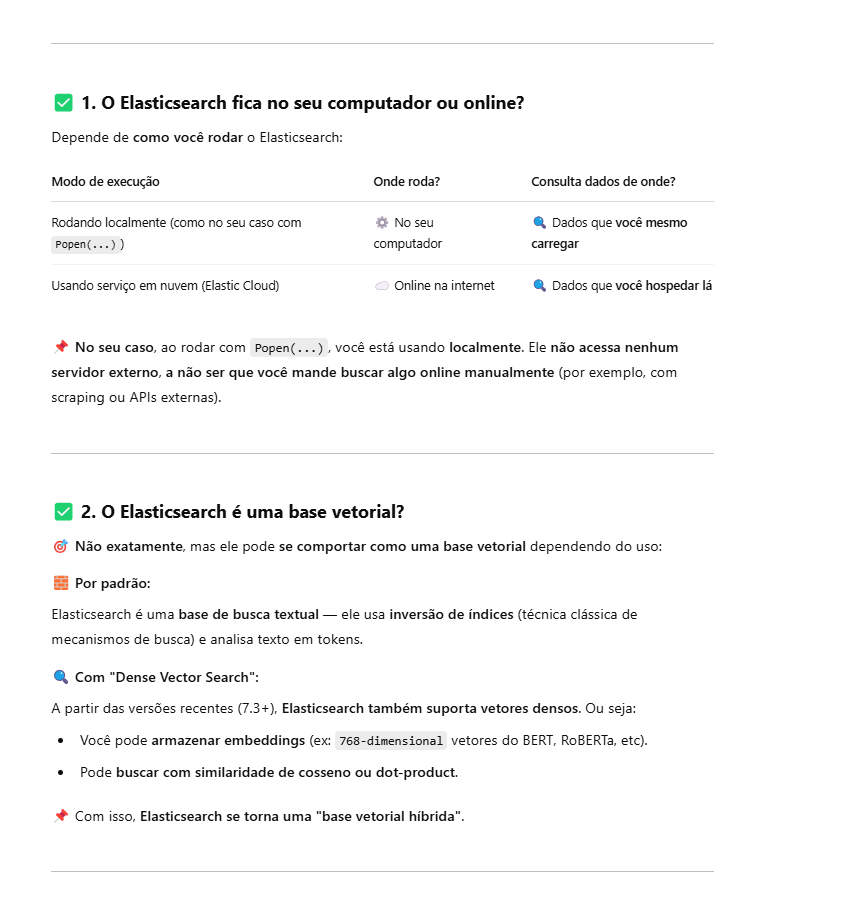

In [1]:

#To initialize the document store, we first need to download and install Elasticsearch
url = """https://artifacts.elastic.co/downloads/elasticsearch/\
elasticsearch-7.9.2-linux-x86_64.tar.gz"""
!wget -nc -q {url}
!tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz

# vamos explorar tanto sparse quanto dense retrievers
# por isso vmaos usar o elasticsearch, que e compativel com os dois

In [2]:
import os
from subprocess import Popen, PIPE, STDOUT
# vamos inciar o server do elastic search
# Run Elasticsearch as a background process
# Altera o dono dos arquivos da pasta para o usuário daemon. Isso ajuda ao iniciar com permissões específicas.
!chown -R daemon:daemon elasticsearch-7.9.2
es_server = Popen(args=['elasticsearch-7.9.2/bin/elasticsearch'],
                  stdout=PIPE, stderr=STDOUT, preexec_fn=lambda: os.setuid(1))
# o popen tem como argumentos as especificações do programa que estmaos executando
# Wait until Elasticsearch has started
!sleep 30

In [5]:
!pip install farm-haystack[colab]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.4/764.4 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 16.3 MB/s eta 0:00:00
  Created wheel for pillow: filename=Pillow-9.0.0-cp311-cp311-linux_x86_64.whl size=1177683 sha256=d16be4a7d486edec0e8af1655b6

In [3]:
# Alternative if Docker is installed ( aqui ele executa pelo docker)
from haystack.utils import launch_es

launch_es()

In [4]:
!curl -X GET "localhost:9200/?pretty"

{
  "name" : "e403d9779dab",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "66NuU4f4TOeo6FTBHGuDpA",
  "version" : {
    "number" : "7.9.2",
    "build_flavor" : "default",
    "build_type" : "tar",
    "build_hash" : "d34da0ea4a966c4e49417f2da2f244e3e97b4e6e",
    "build_date" : "2020-09-23T00:45:33.626720Z",
    "build_snapshot" : false,
    "lucene_version" : "8.6.2",
    "minimum_wire_compatibility_version" : "6.8.0",
    "minimum_index_compatibility_version" : "6.0.0-beta1"
  },
  "tagline" : "You Know, for Search"
}


In [5]:
from haystack.document_stores.elasticsearch import ElasticsearchDocumentStore

# Return the document embedding for later use with dense retriever
document_store = ElasticsearchDocumentStore(return_embedding=True)

ImportError: Failed to import 'elasticsearch'. Run 'pip install farm-haystack[elasticsearch]'.
Note that this installs the Elasticsearch 7 client and requires a running Elasticsearch 7 instance. Starting from Haystack version 1.21 , the 'elasticsearch' extra will install the Elasticsearch 8 client and will require a running Elasticsearch 8 instance. To continue using Elasticsearch 7 with Haystack 1.21 and beyond, install the 'elasticsearch7' extra.
If you want to already start using Elasticsearch 8, install the 'elasticsearch8' extra. Original error: No module named 'elasticsearch'

In [ ]:
# It's a good idea to flush Elasticsearch with each notebook restart
if len(document_store.get_all_documents()) or len(document_store.get_all_labels()) > 0:
    document_store.delete_documents(index="document")
    document_store.delete_documents(index="label")

Since version 1.0 of Haystack, Documents now have a field `content`, which replaces the field `text`. This change was introduced because Documents have become more flexible and can also store tables in addition to texts.

In [ ]:
for split, df in dfs.items():
    # Exclude duplicate reviews
    docs = [{"content": row["context"], "id": row["review_id"],
             "meta":{"item_id": row["title"], "question_id": row["id"],
                     "split": split}}
        for _,row in df.drop_duplicates(subset="context").iterrows()]
    document_store.write_documents(documents=docs, index="document")

print(f"Loaded {document_store.get_document_count()} documents")

#### Initializing a retriever

In Haystack 1.4 `ElasticsearchRetriever` was renamed to `BM25Retriever`. You can still use `ElasticsearchRetriever` for compatibility reasons in version 1.5 but it might be removed in future releases.

In [ ]:
from haystack.nodes.retriever import BM25Retriever

bm25_retriever = BM25Retriever(document_store=document_store)

In [ ]:
item_id = "B0074BW614"
query = "Is it good for reading?"
retrieved_docs = bm25_retriever.retrieve(
    query=query, top_k=3, filters={"item_id":[item_id], "split":["train"]})

In [ ]:
print(retrieved_docs[0])

#### Initializing a reader

In [ ]:
from haystack.nodes import FARMReader

model_ckpt = "deepset/minilm-uncased-squad2" #alternative larger models: deepset/roberta-base-squad2-distilled or deepset/xlm-roberta-large-squad2 or the tiny distilled model: deepset/tinyroberta-squad2
max_seq_length, doc_stride = 384, 128
reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride,
                    return_no_answer=True)

In [ ]:
print(reader.predict_on_texts(question=question, texts=[context], top_k=1))

#### Putting it all together

In [ ]:
from haystack.pipelines import ExtractiveQAPipeline

pipe = ExtractiveQAPipeline(reader=reader, retriever=bm25_retriever)

The format of parameters that can be passed to a pipeline has slightly changed. In the old version, the method call was
```python
preds = pipe.run(query=query, top_k_retriever=3, top_k_reader=n_answers,
                 filters={"item_id": [item_id], "split":["train"]})
```
Now, you can specify the name of the node, e.g., `"Retriever"`, that you want to pass parameters to.

In [ ]:
n_answers = 3
preds = pipe.run(query=query, params={"Retriever": {"top_k": 3, "filters":{"item_id": [item_id], "split":["train"]}},
                                      "Reader": {"top_k": n_answers}})

print(f"Question: {preds['query']} \n")

for idx in range(n_answers):
    print(f"Answer {idx+1}: {preds['answers'][idx].answer}")
    print(f"Review snippet: ...{preds['answers'][idx].context}...")
    print("\n\n")

## Improving Our QA Pipeline

### Evaluating the Retriever

Evaluating the retriever is the same as evaluating a `DocumentSearchPipeline`, which consists only of a single node, a retriever.

In [ ]:
from haystack.pipelines import DocumentSearchPipeline

pipe = DocumentSearchPipeline(retriever=bm25_retriever)

Since version 1.0 of Haystack, `Answer` has become a class and each `Label` contains a `Document` that the `Label` refers to. Thus, the initialization of a `Label` in the following code cell has changed.
Note that the code printed in the book had a small bug. In the for loop of the old code, `Label`s were created that were all initialized with the same id. Thus they were handled as duplicates and not all of them were stored in the document store when we later on called `document_store.write_labels(labels, index="label")`:
```python
for answer in row["answers.text"]:
            label = Label(
                question=row["question"], answer=answer, id=i, origin=row["id"],
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False)
            labels.append(label)
```


*In the previous version there was a bug that omitted some of the labels.*

In [ ]:
from haystack import Label, Answer, Document

labels = []
for i, row in dfs["test"].iterrows():
    # Metadata used for filtering in the Retriever
    meta = {"item_id": row["title"], "question_id": row["id"]}
    # Populate labels for questions with answers
    if len(row["answers.text"]):
        for answer in row["answers.text"]:
            label = Label(
                query=row["question"], answer=Answer(answer=answer), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False, filters={"item_id": [meta["item_id"]], "split":["test"]})
            labels.append(label)
    # Populate labels for questions without answers
    else:
        label = Label(
            query=row["question"], answer=Answer(answer=""), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
            meta=meta, is_correct_answer=True, is_correct_document=True,
            no_answer=True, filters={"item_id": [row["title"]], "split":["test"]})
        labels.append(label)

In [ ]:
document_store.write_labels(labels, index="label")

print(f"""Loaded {document_store.get_label_count(index="label")} \
question-answer pairs""")

In [ ]:
labels_agg = document_store.get_all_labels_aggregated(
    index="label",
    open_domain=True,
    aggregate_by_meta=["item_id"]
)
print(len(labels_agg))

Since version 1.0 of Haystack, the evaluation of pipelines is much different compared to the version described in the first edition of the book. `Pipeline` now has a method `eval()`, which runs the pipeline given input data from labels and returns the prediction and the labels in the format of one Pandas dataframe per pipeline node. This result is stored in `eval_result` in the following code cell. On these results, we can calculate arbitrary metrics - without rerunning the computationally intesive inference steps of the pipeline.

In [ ]:
# We can run the pipeline with the desired top_k value like this
eval_result = pipe.eval(
    labels=labels_agg,
    params={"Retriever": {"top_k": 3}},
)
metrics = eval_result.calculate_metrics()

In [ ]:
print(f"Recall@3: {metrics['Retriever']['recall_single_hit']:.2f}")

You can check the predictions of any query by inspecting the dataframe:

In [ ]:
eval_df = eval_result["Retriever"]
eval_df[eval_df["query"] == "How do you like the lens?"][["query", "filters", "rank", "content", "gold_document_contents", "document_id", "gold_document_ids", "gold_id_match"]]

Or if we want to calculate metrics for multiple topk values, we can run the pipeline only once with the highest top_k value and calculate metrics for smaller top_ks afterwards.

In [ ]:
def evaluate_retriever(retriever, topk_values = [1,3,5,10,20]):
    topk_results = {}
    # Calculate max top_k
    max_top_k = max(topk_values)
    # Create Pipeline
    p = DocumentSearchPipeline(retriever=retriever)
    # Run inference with max top_k by looping over each question-answers pair in test set
    eval_result = p.eval(
        labels=labels_agg,
        params={"Retriever": {"top_k": max_top_k}},
    )
    # Calculate metric for each top_k value
    for topk in topk_values:
        # Get metrics
        metrics = eval_result.calculate_metrics(simulated_top_k_retriever=topk)
        topk_results[topk] = {"recall": metrics["Retriever"]["recall_single_hit"]}

    return pd.DataFrame.from_dict(topk_results, orient="index")


bm25_topk_df = evaluate_retriever(bm25_retriever)

In [ ]:
def plot_retriever_eval(dfs, retriever_names):
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name)
    plt.xticks(df.index)
    plt.ylabel("Top-k Recall")
    plt.xlabel("k")
    plt.show()

plot_retriever_eval([bm25_topk_df], ["BM25"])

#### Dense Passage Retrieval

<img alt="DPR Architecture" caption="DPR's bi-encoder architecture for computing the relevance of a document and query" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_dpr.png?raw=1" id="dpr"/>

In [ ]:
from haystack.nodes import DensePassageRetriever

dpr_retriever = DensePassageRetriever(document_store=document_store,
    query_embedding_model="facebook/dpr-question_encoder-single-nq-base",
    passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base",
    embed_title=False)

In [ ]:
document_store.update_embeddings(retriever=dpr_retriever)

In [ ]:
dpr_topk_df = evaluate_retriever(dpr_retriever)
plot_retriever_eval([bm25_topk_df, dpr_topk_df], ["BM25", "DPR"])

### Evaluating the Reader

In [ ]:
from haystack.modeling.evaluation.squad import compute_f1, compute_exact

pred = "about 6000 hours"
label = "6000 hours"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

In [ ]:
pred = "about 6000 dollars"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

The evaluation of a reader can be done by creating a pipeline that consists only of a single node: a reader. In this case, the `pipeline.eval()` gets the relevant documents as direct input from the labels.

In [ ]:
from haystack.pipelines import Pipeline
def evaluate_reader(reader):
    score_keys = ['exact_match', 'f1']
    p = Pipeline()
    p.add_node(component=reader, name="Reader", inputs=["Query"])

    eval_result = p.eval(
        labels=labels_agg,
        documents= [[label.document for label in multilabel.labels] for multilabel in labels_agg],
        params={},
    )
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)

    return {k:v for k,v in metrics["Reader"].items() if k in score_keys}

reader_eval = {}
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader)

In the first version no_answer labels weren't taken into account. Because there are quite many of them in the evaluation dataset the numbers differ significantly compared to the first version (EM was at ~0.07 and f1 at ~0.25).

In [ ]:
def plot_reader_eval(reader_eval):
    fig, ax = plt.subplots()
    df = pd.DataFrame.from_dict(reader_eval).reindex(["exact_match", "f1"])
    df.plot(kind="bar", ylabel="Score", rot=0, ax=ax)
    ax.set_xticklabels(["EM", "F1"])
    plt.legend(loc='upper left')
    plt.show()

plot_reader_eval(reader_eval)

### Domain Adaptation

<img alt="SQuAD Schema" caption="Visualization of the SQuAD JSON format" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-schema.png?raw=1" id="squad-schema"/>

In [ ]:
def create_paragraphs(df):
    paragraphs = []
    id2context = dict(zip(df["review_id"], df["context"]))
    for review_id, review in id2context.items():
        qas = []
        # Filter for all question-answer pairs about a specific context
        review_df = df.query(f"review_id == '{review_id}'")
        id2question = dict(zip(review_df["id"], review_df["question"]))
        # Build up the qas array
        for qid, question in id2question.items():
            # Filter for a single question ID
            question_df = df.query(f"id == '{qid}'").to_dict(orient="list")
            ans_start_idxs = question_df["answers.answer_start"][0].tolist()
            ans_text = question_df["answers.text"][0].tolist()
            # Fill answerable questions
            if len(ans_start_idxs):
                answers = [
                    {"text": text, "answer_start": answer_start}
                    for text, answer_start in zip(ans_text, ans_start_idxs)]
                is_impossible = False
            else:
                answers = []
                is_impossible = True
            # Add question-answer pairs to qas
            qas.append({"question": question, "id": qid,
                        "is_impossible": is_impossible, "answers": answers})
        # Add context and question-answer pairs to paragraphs
        paragraphs.append({"qas": qas, "context": review})
    return paragraphs

In [ ]:
product = dfs["train"].query("title == 'B00001P4ZH'")
create_paragraphs(product)

In [ ]:
import json

def convert_to_squad(dfs):
    for split, df in dfs.items():
        subjqa_data = {}
        # Create `paragraphs` for each product ID
        groups = (df.groupby("title").apply(create_paragraphs)
            .to_frame(name="paragraphs").reset_index())
        subjqa_data["data"] = groups.to_dict(orient="records")
        # Save the result to disk
        with open(f"electronics-{split}.json", "w+", encoding="utf-8") as f:
            json.dump(subjqa_data, f)

convert_to_squad(dfs)

In [ ]:
train_filename = "electronics-train.json"
dev_filename = "electronics-validation.json"

reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

In [ ]:
reader_eval["Fine-tune on SQuAD + SubjQA"] = evaluate_reader(reader)

In [ ]:
plot_reader_eval(reader_eval)

In [ ]:
minilm_ckpt = "microsoft/MiniLM-L12-H384-uncased"
minilm_reader = FARMReader(model_name_or_path=minilm_ckpt, progress_bar=False,
                           max_seq_len=max_seq_length, doc_stride=doc_stride,
                           return_no_answer=True)

In [ ]:
minilm_reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

In [ ]:
reader_eval["Fine-tune on SubjQA"] = evaluate_reader(minilm_reader)

In [ ]:
plot_reader_eval(reader_eval)

### Evaluating the Whole QA Pipeline

In [ ]:
from haystack.pipelines import ExtractiveQAPipeline
pipe = ExtractiveQAPipeline(retriever=bm25_retriever, reader=reader)

# Evaluate!
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
# Extract metrics from reader
reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

In [ ]:
#id reader-vs-pipeline
#caption Comparison of EM and _F_~1~ scores for the reader against the whole QA pipeline
plot_reader_eval({"Reader": reader_eval["Fine-tune on SQuAD + SubjQA"],
                  "QA pipeline (top-1)": reader_eval["QA Pipeline (top-1)"]})

In [ ]:
# Or get QA pipeline and Reader metrics in one shot:
# Reader evaluation is run a second time using simulated perfect retriever results
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
    add_isolated_node_eval=True
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
# Extract metrics from reader run in isolation with simulated perfect retriever
isolated_metrics = eval_result.calculate_metrics(simulated_top_k_reader=1, eval_mode="isolated")

pipeline_reader_eval = {}
pipeline_reader_eval["Reader"] = {
    k:v for k,v in isolated_metrics["Reader"].items()
    if k in ["exact_match", "f1"]}
pipeline_reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

plot_reader_eval(pipeline_reader_eval)

## Going Beyond Extractive QA

<img alt="RAG Architecture" width="600" caption="The RAG architecture for fine-tuning a retriever and generator end-to-end (courtesy of Ethan Perez)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_rag-architecture.png?raw=1" id="rag"/>

### Retrieval-Augmented Generation

In [ ]:
from haystack.nodes import RAGenerator

generator = RAGenerator(model_name_or_path="facebook/rag-token-nq",
                        embed_title=False, num_beams=5)

In [ ]:
from haystack.pipelines import GenerativeQAPipeline

pipe = GenerativeQAPipeline(generator=generator, retriever=dpr_retriever)

In [ ]:
def generate_answers(query, top_k_generator=3):
    preds = pipe.run(query=query,
                     params={"Retriever": {"top_k":5,
                                  "filters":{"item_id": ["B0074BW614"]}},
                             "Generator": {"top_k": top_k_generator}})
    print(f"Question: {preds['query']} \n")
    for idx in range(top_k_generator):
        print(f"Answer {idx+1}: {preds['answers'][idx].answer}")

In [ ]:
generate_answers(query)

In [ ]:
generate_answers("What is the main drawback?")

## Conclusion

<img alt="QA Pyramid" caption="The QA hierarchy of needs" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_qa-pyramid.png?raw=1" id="qa-pyramid"/>